# 05 — Comparación de detectores y decisión de diseño (Fase D)

Este notebook consume exclusivamente los artefactos OOS generados por
`04_benchmark_detectores.ipynb`. No vuelve a ajustar modelos, no modifica sus
configuraciones y no mezcla las pistas A y B en un ranking único.

> **Objetivo.** Resumir sensibilidad, especificidad, persistencia, estabilidad y
> coste; detectar dominancias y tensiones; dejar una base auditable para decidir más
> adelante entre un detector único, un híbrido o un diseño nuevo. El notebook no
> declara automáticamente un ganador.


In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
ROOT = Path.cwd()
while not (ROOT / 'data' / 'benchmark_spec.yaml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src import benchmark as bm

OUTPUT_DIR = ROOT / 'results' / 'benchmark_v2'
pd.set_option('display.max_columns', 120)
print('Resultados:', OUTPUT_DIR.relative_to(ROOT))


Resultados: results\benchmark_v2


## 1. Carga e inventario

Se espera una fila por pista y detector. Una comparación con menos de 12 detectores
puede usarse como diagnóstico, pero debe rotularse como **parcial** y no fundamentar
la decisión final. Las filas A y B nunca compiten directamente: A aporta profundidad
histórica y B riqueza multi-activo.


In [2]:
try:
    metrics = bm.load_metrics(OUTPUT_DIR)
    HAY_RESULTADOS = True
except FileNotFoundError as exc:
    metrics = pd.DataFrame()
    HAY_RESULTADOS = False
    print(exc)

if HAY_RESULTADOS:
    inventario = metrics.groupby('pista')['id'].agg(['count', lambda s: ', '.join(sorted(s))])
    inventario.columns = ['n_detectores', 'ids']
    display(inventario)
    completo = metrics.groupby('pista')['id'].nunique().reindex(['A', 'B'], fill_value=0)
    BENCHMARK_COMPLETO = bool((completo == 12).all())
    print('Benchmark completo:', BENCHMARK_COMPLETO)
else:
    BENCHMARK_COMPLETO = False


,n_detectores,ids
pista,,
A,12,"D01, D02, D03, D04, D05, D06, D07, D08, D09, D..."
B,12,"D01, D02, D03, D04, D05, D06, D07, D08, D09, D..."


Benchmark completo: True


## 2. Gate de comparabilidad

Antes de ordenar métricas verificamos que dentro de cada pista todos los detectores
comparten inicio y fin OOS, que no hay duplicados `(pista, id)` y que la ventana de
entrenamiento declarada es común. Las distintas frecuencias de *refit* son parte de
la configuración computacional de cada familia, no ventanas de evaluación distintas.

Una discrepancia detiene la interpretación: no se arregla rellenando ni recortando
resultados después de verlos.


In [3]:
if HAY_RESULTADOS:
    duplicates = metrics.duplicated(['pista', 'id']).sum()
    checks = metrics.groupby('pista').agg(
        detectores=('id', 'nunique'),
        inicios_oos=('oos_start', 'nunique'),
        finales_oos=('oos_end', 'nunique'),
        train_configs=('train_days', 'nunique'),
    )
    display(checks)
    print('Duplicados pista/id:', duplicates)
    COMPARABLE = bool(
        duplicates == 0
        and (checks['inicios_oos'] == 1).all()
        and (checks['finales_oos'] == 1).all()
        and (checks['train_configs'] == 1).all()
    )
    print('Gate de comparabilidad:', 'OK' if COMPARABLE else 'FALLA')
else:
    COMPARABLE = False

LISTO_COMPARAR = bool(BENCHMARK_COMPLETO and COMPARABLE)
if HAY_RESULTADOS and not BENCHMARK_COMPLETO:
    print('Comparación final bloqueada: faltan detectores; termina primero el notebook 04.')


,detectores,inicios_oos,finales_oos,train_configs
pista,,,,
A,12,1,1,1
B,12,1,1,1


Duplicados pista/id: 0
Gate de comparabilidad: OK


## 3. Métricas agregadas y ranking descriptivo

La cobertura media resume únicamente crisis que realmente caen en la ventana OOS;
los `NaN` no se convierten en cero. La activación media en trampas debe ser baja.
El ranking combina cinco ejes independientes con el mismo peso:

- cobertura de crisis ↑;
- falsas alarmas globales ↓;
- activación en trampas ↓;
- switching ↓;
- estabilidad de etiquetas ↑.

La duración media se conserva como diagnóstico, pero no entra en el promedio:
es una transformación monótona del número de cambios y duplicaría el peso del switching.

Es un **mapa descriptivo**, no una función de utilidad definitiva. Un promedio puede
ocultar que dos detectores resuelven problemas diferentes.


In [4]:
if LISTO_COMPARAR:
    comparison = bm.rank_within_track(metrics)
    scorecard_cols = [
        'pista', 'puesto_pista', 'id', 'detector', 'familia',
        'mean_crisis_coverage', 'false_alarm_rate', 'mean_trap_activation',
        'switching_rate', 'mean_regime_duration', 'label_stability',
        'elapsed_seconds', 'rank_medio',
    ]
    display(comparison[scorecard_cols].round(4))

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    comparison.to_csv(OUTPUT_DIR / 'metrics_master_v2.csv', index=False)
    comparison[scorecard_cols].to_csv(OUTPUT_DIR / 'ranking_v2.csv', index=False)
    print('Exportados metrics_master_v2.csv y ranking_v2.csv')


,pista,puesto_pista,id,detector,familia,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds,rank_medio
6,A,1.0,D07,changepoint_online,Change-point,0.6463,0.6718,0.0000,0.0022,441.6562,1.0000,39.9900,3.9
0,A,2.0,D01,rule_vix_threshold,Reglas,0.5185,0.5764,0.0000,0.0105,94.2200,0.9996,18.5395,4.1
1,A,3.0,D02,rule_composite_riskoff,Reglas,0.4077,0.5085,0.0000,0.0059,168.2500,0.9992,12.7200,4.3
9,A,4.0,D10,turbulence_mahalanobis,Reglas multivariantes,0.4630,0.5383,0.0000,0.0443,22.5407,0.9991,848.2449,5.5
8,A,5.0,D09,jump_model_k2_lam50,Jump model,0.3332,0.5988,0.0000,0.0036,271.7885,0.9968,2970.4268,5.9
3,A,6.0,D04,hmm_gaussian_2s,HMM,0.7925,0.7104,0.0000,0.0172,57.9221,0.9766,4668.4376,6.5
5,A,7.0,D06,garch_t_vol,GARCH,0.7302,0.6229,0.0789,0.0173,57.4512,0.9990,93.6229,7.0
4,A,8.0,D05,markov_switching_var_2s,Markov-Switching,0.7313,0.6245,0.0316,0.0683,14.6304,0.9952,2502.3981,7.8
11,A,8.0,D12,deep_ae_regime_k2,Deep learning,0.5604,0.6077,0.0053,0.1811,5.5207,0.9953,241.9966,7.8
2,A,10.0,D03,clustering_gmm_k3,Clustering,0.5571,0.5885,0.0105,0.0988,10.1094,0.9758,415.8152,8.2


Exportados metrics_master_v2.csv y ranking_v2.csv


## 4. Sensibilidad frente a especificidad

El gráfico enfrenta cobertura media OOS con la fracción de señales de crisis que
caen fuera del catálogo. La zona deseable está arriba a la izquierda. Las pistas se
dibujan por separado para no confundir profundidad histórica con riqueza de señales.


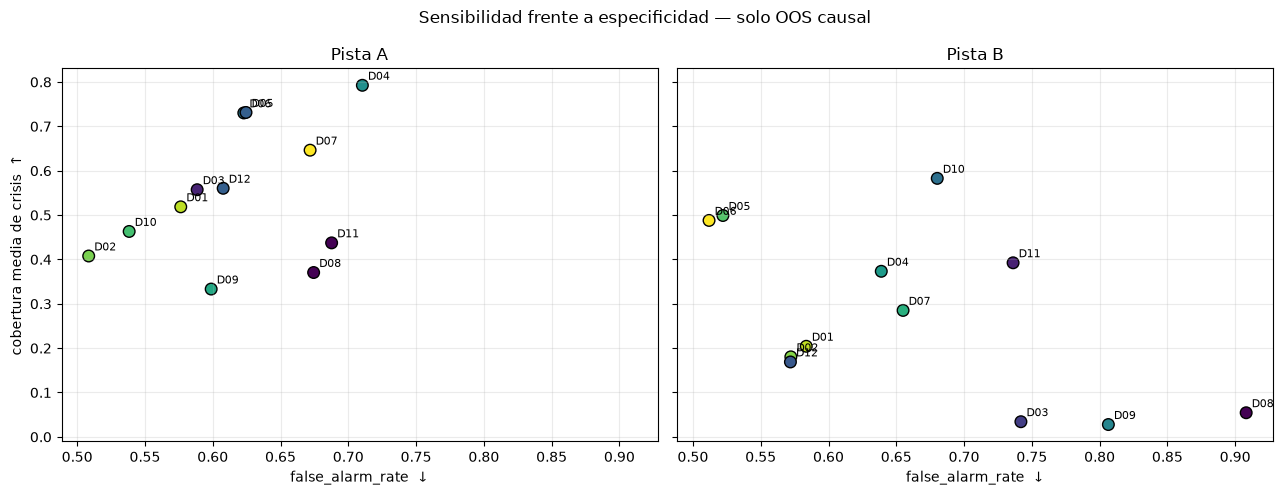

In [5]:
if LISTO_COMPARAR:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
    for ax, track in zip(axes, ['A', 'B']):
        part = comparison[comparison.pista == track]
        ax.scatter(part.false_alarm_rate, part.mean_crisis_coverage,
                   s=70, c=part.puesto_pista, cmap='viridis_r', edgecolor='black')
        for _, row in part.iterrows():
            ax.annotate(row.id, (row.false_alarm_rate, row.mean_crisis_coverage),
                        xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set_title(f'Pista {track}')
        ax.set_xlabel('false_alarm_rate  ↓')
        ax.grid(alpha=.25)
    axes[0].set_ylabel('cobertura media de crisis  ↑')
    fig.suptitle('Sensibilidad frente a especificidad — solo OOS causal')
    fig.tight_layout()
    plt.show()


## 5. Persistencia, estabilidad y coste

La detección útil no debe comprar cobertura mediante *flickering*. Se revisan
duración media y estabilidad junto al coste real medido. El tiempo no entra en el
ranking estadístico: sirve para decidir si una mejora marginal es operativamente
razonable.


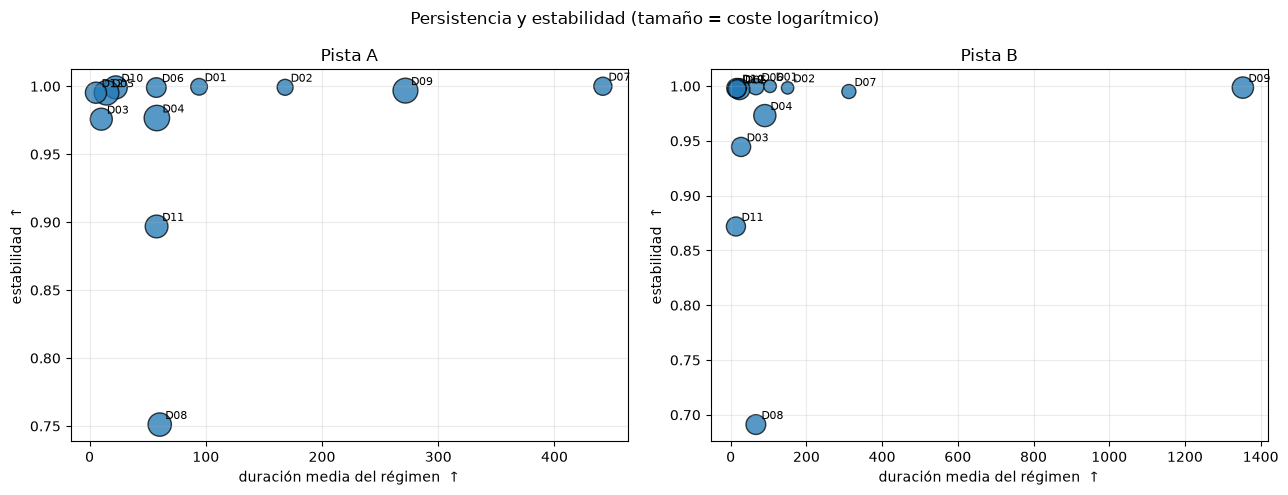

In [6]:
if LISTO_COMPARAR:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, track in zip(axes, ['A', 'B']):
        part = comparison[comparison.pista == track]
        sizes = 40 + 35 * np.log1p(part.elapsed_seconds.fillna(0))
        ax.scatter(part.mean_regime_duration, part.label_stability,
                   s=sizes, alpha=.75, edgecolor='black')
        for _, row in part.iterrows():
            ax.annotate(row.id, (row.mean_regime_duration, row.label_stability),
                        xytext=(4, 4), textcoords='offset points', fontsize=8)
        ax.set_title(f'Pista {track}')
        ax.set_xlabel('duración media del régimen  ↑')
        ax.set_ylabel('estabilidad  ↑')
        ax.grid(alpha=.25)
    fig.suptitle('Persistencia y estabilidad (tamaño = coste logarítmico)')
    fig.tight_layout()
    plt.show()


## 6. Mapa de ranks por dimensión

El mapa evita que `rank_medio` oculte especialización: una fila puede dominar en
alerta temprana y quedar atrás en persistencia. Se interpreta por pista y por eje,
nunca como evidencia de superioridad universal.


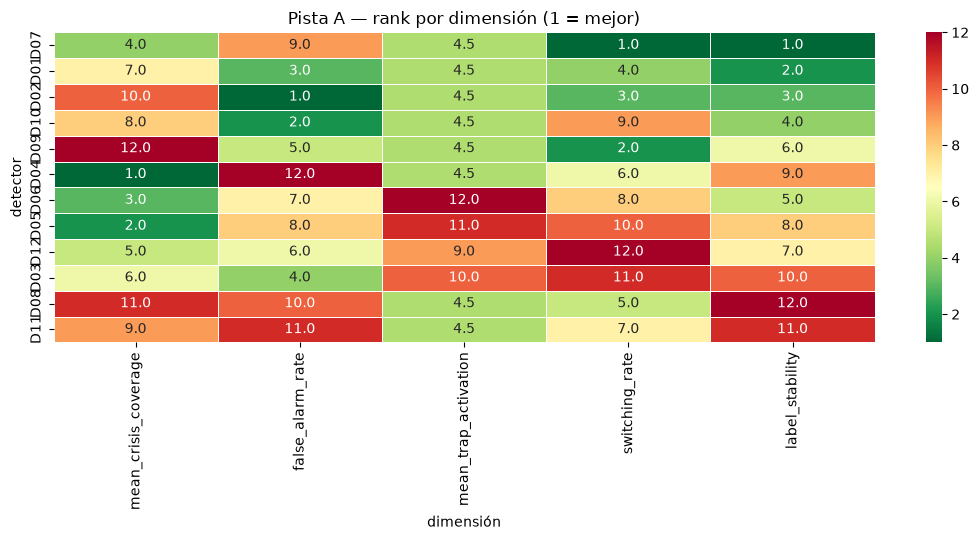

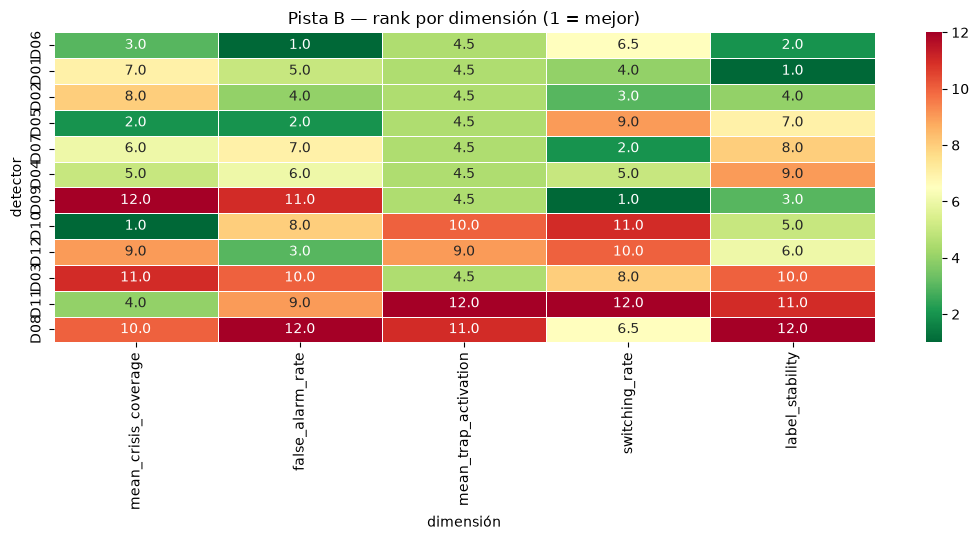

In [7]:
if LISTO_COMPARAR:
    rank_cols = [c for c in comparison if c.startswith('rank_') and c != 'rank_medio']
    for track in ['A', 'B']:
        part = comparison[comparison.pista == track].set_index('id')[rank_cols]
        part.columns = [c.removeprefix('rank_') for c in part.columns]
        plt.figure(figsize=(11, 5.5))
        sns.heatmap(part, annot=True, fmt='.1f', cmap='RdYlGn_r', linewidths=.4)
        plt.title(f'Pista {track} — rank por dimensión (1 = mejor)')
        plt.xlabel('dimensión')
        plt.ylabel('detector')
        plt.tight_layout()
        plt.show()


## 7. Qué se decide después — no en este notebook

La evidencia anterior permite formular tres alternativas, pero no escogerlas antes
de ver un benchmark completo y comparable:

1. **Detector único:** si un modelo domina de forma estable en ambas pistas.
2. **Híbrido de dos velocidades:** un núcleo de régimen persistente acompañado por
   una alarma rápida, si sus errores son complementarios.
3. **Detector nuevo:** solo si ningún candidato satisface simultáneamente cobertura,
   disciplina y estabilidad, y siempre comparado contra estos baselines.

La decisión deberá escribirse en una ADR y congelar modelo, features, hiperparámetros
y regla de refit. Después se realizará la prueba pseudolive diaria sobre un periodo
final no utilizado para elegir esa configuración.


In [8]:
if LISTO_COMPARAR:
    podium = comparison.loc[comparison.groupby('pista')['puesto_pista'].transform('min')
                            == comparison['puesto_pista'], scorecard_cols]
    print('Podio descriptivo por pista (no decisión final):')
    display(podium.round(4))
else:
    print('Pendiente: completar y validar 04_benchmark_detectores.ipynb.')


Podio descriptivo por pista (no decisión final):


,pista,puesto_pista,id,detector,familia,mean_crisis_coverage,false_alarm_rate,mean_trap_activation,switching_rate,mean_regime_duration,label_stability,elapsed_seconds,rank_medio
6,A,1.0,D07,changepoint_online,Change-point,0.6463,0.6718,0.0,0.0022,441.6562,1.0000,39.9900,3.9
17,B,1.0,D06,garch_t_vol,GARCH,0.4879,0.5119,0.0,0.0148,66.5410,0.9995,14.3589,3.4


## 8. Cierre

`05_comparacion_detectores.ipynb` produce una comparación reproducible, no una
conclusión automática. El entregable de esta etapa son el master v2, el ranking por
dimensiones, los gráficos y una lista explícita de incompatibilidades o fallos.

Solo después de revisar esa evidencia se decidirá si el TFM adopta uno de los doce,
combina dos mecanismos o justifica un detector nuevo.
